In [22]:
import pandas as pd
from io import StringIO

customers = '''
CustomerID,Age,Annual_Income,Spending_Score
1,19,15,39
2,21,15,81
3,20,16,6
4,23,16,77
5,31,17,40
6,22,17,76
7,35,18,6
8,23,18,94
9,64,19,3
10,30,19,72
11,67,20,14
12,35,20,99
13,58,21,15
14,24,21,77
15,37,22,13
'''

# 문자열 → 파일처럼 읽기
df = pd.read_csv(StringIO(customers))

print(df.head())

   CustomerID  Age  Annual_Income  Spending_Score
0           1   19             15              39
1           2   21             15              81
2           3   20             16               6
3           4   23             16              77
4           5   31             17              40


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[["Annual_Income", "Spending_Score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df)

    CustomerID  Age  Annual_Income  Spending_Score  Cluster
0            1   19             15              39        2
1            2   21             15              81        0
2            3   20             16               6        2
3            4   23             16              77        0
4            5   31             17              40        2
5            6   22             17              76        0
6            7   35             18               6        2
7            8   23             18              94        0
8            9   64             19               3        1
9           10   30             19              72        0
10          11   67             20              14        1
11          12   35             20              99        0
12          13   58             21              15        1
13          14   24             21              77        1
14          15   37             22              13        1


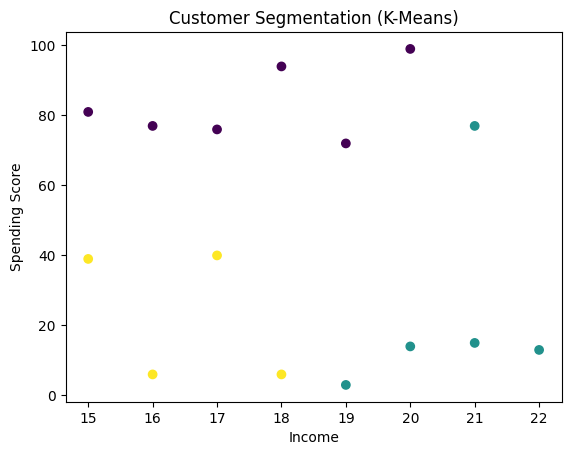

In [25]:
import matplotlib.pyplot as plt

plt.scatter(df["Annual_Income"], df["Spending_Score"], c=df["Cluster"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (K-Means)")
plt.show()

```
군집화 실습 : 고객 세그먼테이션
비지도학습 알고리즘의 하나인 군집화의 기능적 의미 ⇒ 숨어 있는 새로운 집단을 발견하는 것
새로운 군집 내의 데이터 값을 분석하고 이해함으로써, 집단에 새로운 의미를 부여하고
전체 데이터를 다른 각도로 바라볼 수 있게 만들어줌
```


```
🧠 해석 예시
Cluster 0 → 저소득 + 저소비
Cluster 1 → 고소득 + 고소비 (VIP)
Cluster 2 → 고소득 + 저소비 (잠재 고객)
```

In [26]:
print(df.groupby("Cluster").mean())

         CustomerID        Age  Annual_Income  Spending_Score
Cluster                                                      
0               7.0  25.666667           17.5       83.166667
1              12.4  50.000000           20.6       24.400000
2               4.0  26.250000           16.5       22.750000


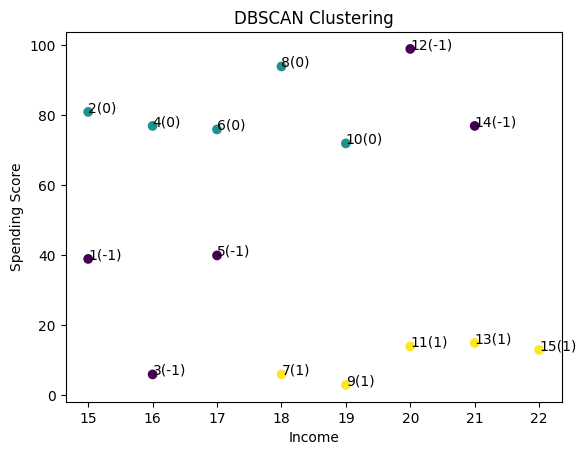

In [48]:
from sklearn.cluster import DBSCAN

# 🔧 2. min_samples 튜닝
# 📌 기본 추천
# min_samples = 2 * feature 개수

# 예:

# feature 2개 → 4
# feature 4개 → 8

db = DBSCAN(eps=0.8, min_samples=3)

df["DBSCAN"] = db.fit_predict(X_scaled)

for i in range(len(df)):
    plt.text(
        df["Annual_Income"][i],
        df["Spending_Score"][i],
        f"{df['CustomerID'][i]}({df['DBSCAN'][i]})"
    )

plt.scatter(df["Annual_Income"], df["Spending_Score"], c=df["DBSCAN"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")
plt.show()

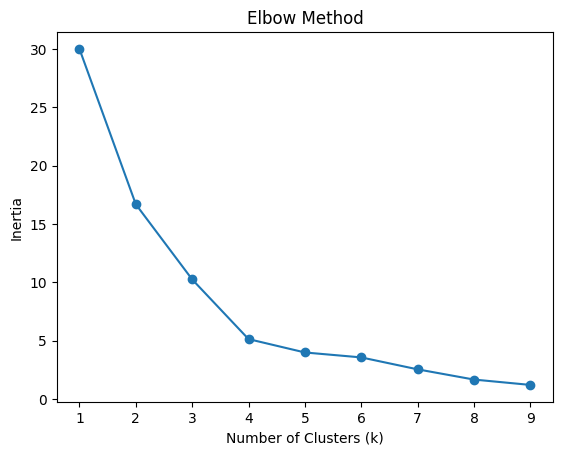

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# k 후보들
K = range(1, 10)

inertia = []

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)  # 스케일된 데이터 사용
    inertia.append(model.inertia_)

# 그래프
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

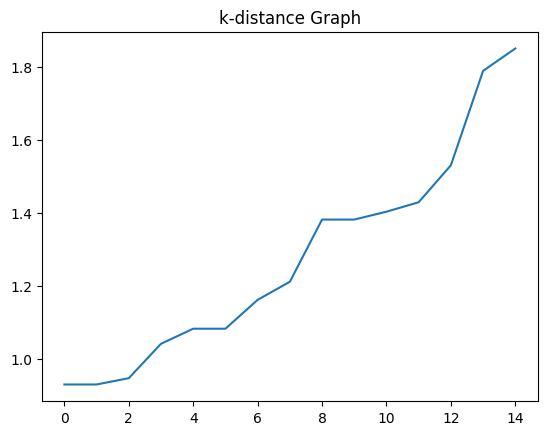

In [40]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)

distances, _ = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title("k-distance Graph")
plt.show()